# validation of Neural Likelihood

In [1]:
import numpy as np
from tqdm import tqdm

In [2]:
import torch
import tarp
from mira_score import mira
from sbi.inference import NPE

In [3]:
from px2cosmo import fm as FM 
from px2cosmo import util as UT

In [4]:
import corner as DFM
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

# validate $z=14$ NLE

In [5]:
# construct test data
Nmocks = 1000
_test_omegas = np.array([
    np.random.uniform(-1.8, -1.5, size=Nmocks), 
    np.random.uniform(-1.8, -1.2, size=Nmocks),
    np.random.uniform(-0.4, 0, size=Nmocks), 
    np.random.uniform(-22., -18., size=Nmocks)
]).T

test_omegas, test_Xsig = [], []
for i in tqdm(range(Nmocks)): 
    # forward model 
    _mock = FM.forwardmodel(_test_omegas[i], name='z14', phi_amp=6e-3)

    test_omegas.append(np.tile(_test_omegas[i], (_mock.shape[0],1)))
    test_Xsig.append(_mock)
    
test_omegas = np.vstack(test_omegas)
test_Xsig = np.vstack(test_Xsig)

test_omegasig = torch.tensor(np.hstack([test_omegas, test_Xsig[:,-2:]]).astype(np.float32))
test_X = torch.tensor(test_Xsig[:,:2].astype(np.float32))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:59<00:00, 16.80it/s]


load best NLE

In [6]:
p_X_omegasig_S_z14 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z14_batch50/q_X_omegasig_z14_batch50.20.pt', weights_only=False)

### validate NLE

  0%|          | 0/10000 [00:00<?, ?it/s]

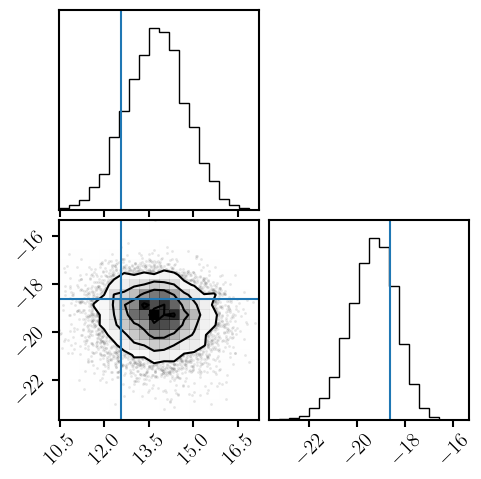

  0%|          | 0/10000 [00:00<?, ?it/s]

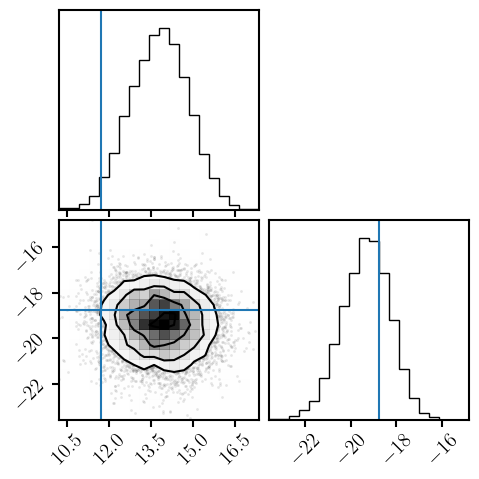

  0%|          | 0/10000 [00:00<?, ?it/s]

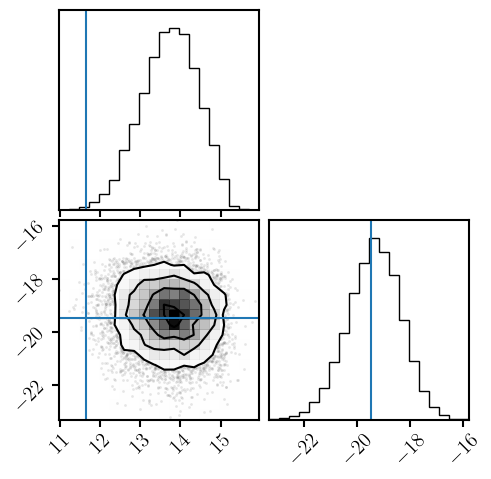

In [7]:
for i in range(3):
    samples = p_X_omegasig_S_z14.sample((10000,), x=test_omegasig[i]).cpu().numpy()
    fig = DFM.corner(samples)
    DFM.overplot_lines(fig, test_X[i].cpu())
    plt.show()

In [8]:
L = 1000
ichoose = np.random.choice(np.arange(test_omegasig.shape[0]), size=L, replace=False)

In [9]:
test_samples = p_X_omegasig_S_z14.sample_batched((1000,), x=test_omegasig[ichoose], show_progress_bars=False)
ecp_z14, alpha_z14 = tarp.get_tarp_coverage(test_samples.cpu().numpy(), test_X[ichoose].cpu().numpy())
mean_score_z14, std_score_z14 = mira(test_X[ichoose], test_samples[None,:].permute(0, 2, 1, 3), num_runs=100)

Mira MC runs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 264.25it/s]


(0.0, 1.0)

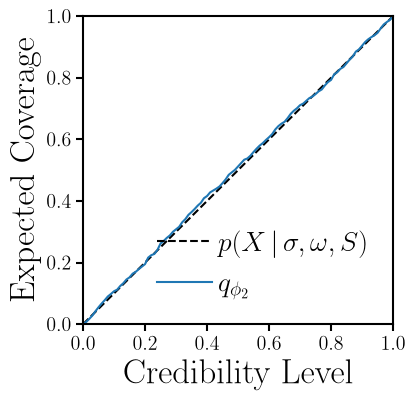

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label=r'$p(X\,|\,\sigma, \omega,S)$')
ax.plot(alpha_z14, ecp_z14, label=r'$q_{\phi_2}$')
ax.legend(fontsize=20, handletextpad=0.2)
ax.set_ylabel("Expected Coverage", fontsize=25)
ax.set_ylim(0, 1)
ax.set_xlabel("Credibility Level", fontsize=25)
ax.set_xlim(0, 1)

Text(0, 0.5, 'MIRA score')

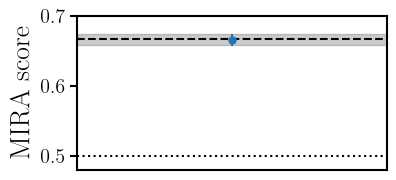

In [11]:
fig = plt.figure(figsize=(4,2))
sub = fig.add_subplot(111)
sub.fill_between([0., 1.], [2/3+np.sqrt(1/18/L), 2/3+np.sqrt(1/18/L)], [2/3-np.sqrt(1/18/L), 2/3-np.sqrt(1/18/L)], edgecolor='none', color='k', alpha=0.2)
sub.plot([0., 1.], [2/3, 2/3], c='k', ls='--')
sub.plot([0., 1.], [0.5, 0.5], c='k', ls=':')
sub.errorbar([0.5], [mean_score_z14.item()], yerr=[std_score_z14.item()], fmt='o', markersize=5)
sub.set_xlim(0., 1.)
sub.set_xticks([])
sub.set_ylim(0.48, 0.7)
sub.set_ylabel('MIRA score', fontsize=20)

  0%|          | 0/10000 [00:00<?, ?it/s]

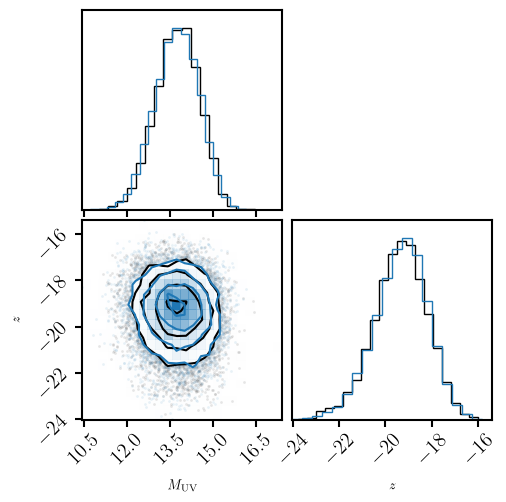

  0%|          | 0/10000 [00:00<?, ?it/s]

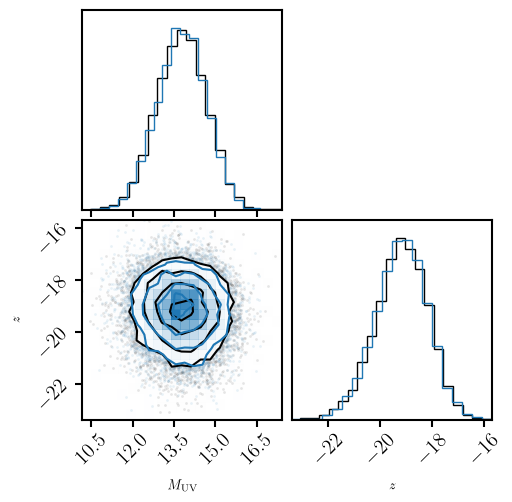

  0%|          | 0/10000 [00:00<?, ?it/s]

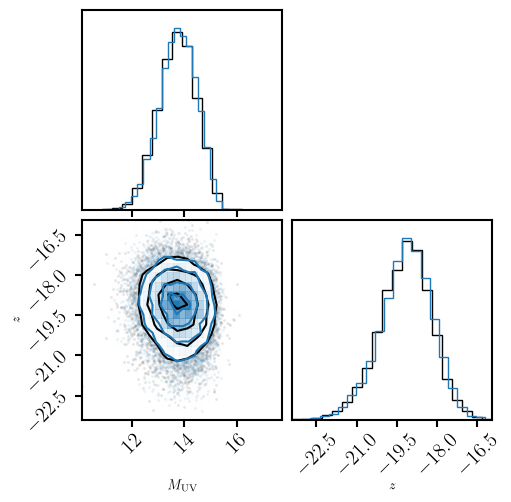

  0%|          | 0/10000 [00:00<?, ?it/s]

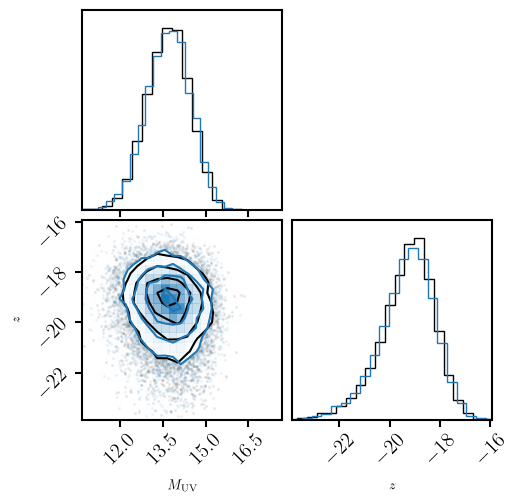

  0%|          | 0/10000 [00:00<?, ?it/s]

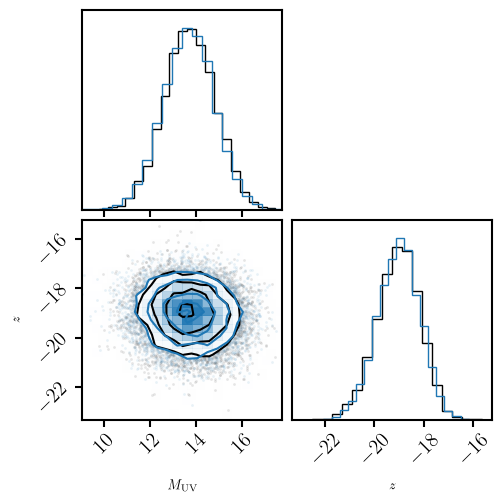

  0%|          | 0/10000 [00:00<?, ?it/s]

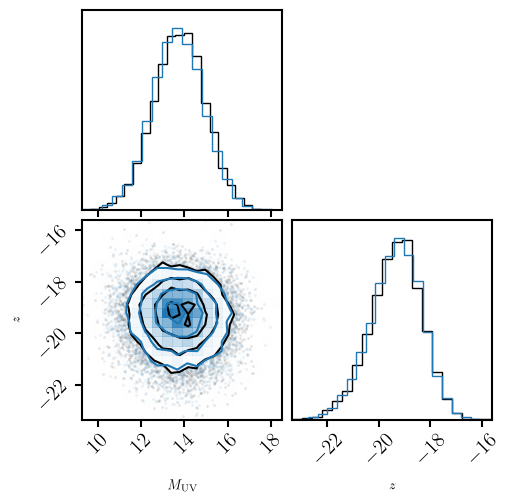

  0%|          | 0/10000 [00:00<?, ?it/s]

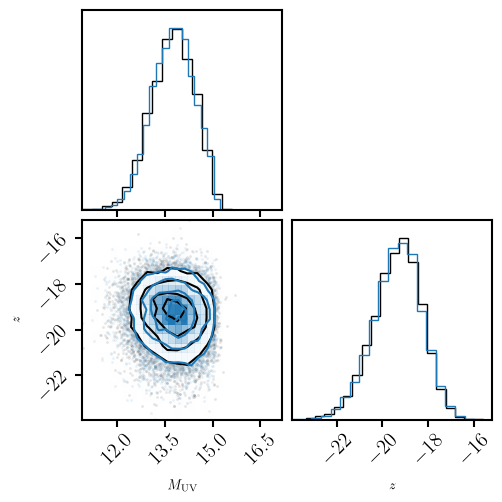

  0%|          | 0/10000 [00:00<?, ?it/s]

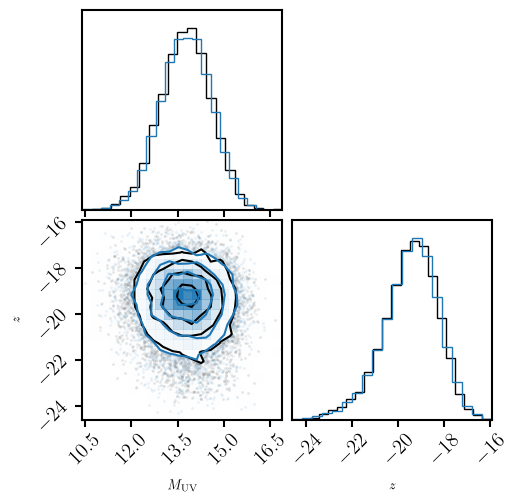

  0%|          | 0/10000 [00:00<?, ?it/s]

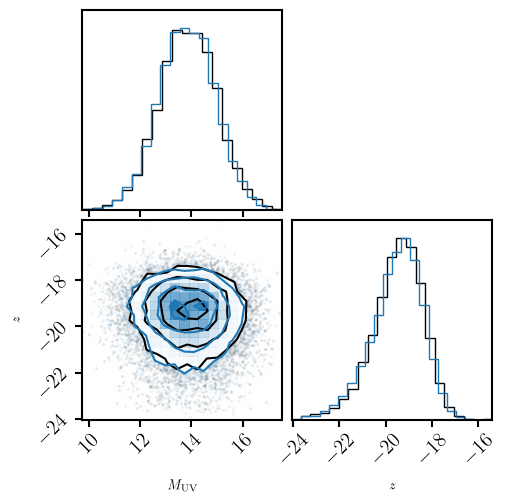

  0%|          | 0/10000 [00:00<?, ?it/s]

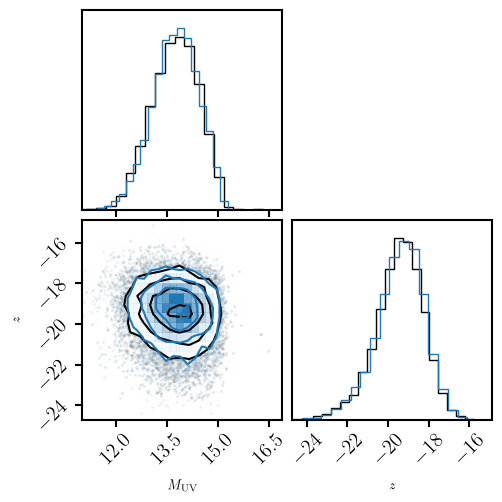

In [12]:
for i in np.random.choice(np.arange(test_X.shape[0]), size=10, replace=False): 
    _omega = test_omegas[i]
    _sig_z = test_Xsig[i,-2]
    _sig_Muv = test_Xsig[i,-1]

    Ng = 0
    mocks = [] 
    while Ng < 10000: 
        mock = FM.sampleLF(_omega, phi_amp=6e-3)
        select = FM.selection_function(mock, name='z14') 
        mock = mock[select]
        
        mock[:,0] += _sig_z * np.random.normal(size=mock.shape[0])
        mock[:,1] += _sig_Muv * np.random.normal(size=mock.shape[0])
        mocks.append(mock)
        Ng += mock.shape[0]
    mocks = np.vstack(mocks)
    
    _omegasig = np.concatenate([_omega, [_sig_z, _sig_Muv]])
    samples = p_X_omegasig_S_z14.sample((10000,), x=torch.tensor(_omegasig.astype(np.float32))).cpu()
    fig = DFM.corner(samples.numpy(), labels=[r"$M_{\rm UV}$", "$z$"], hist_kwargs={'density':True})
    _ = DFM.corner(mocks, labels=[r"$M_{\rm UV}$", "$z$"], fig=fig, color='C0', hist_kwargs={'density':True})
    plt.show()

# validate $z=11$ NLE

In [13]:
# construct test data
test_omegas, test_Xsig = [], []
for i in tqdm(range(Nmocks)): 
    # forward model 
    _mock = FM.forwardmodel(_test_omegas[i], name='z11', phi_amp=6e-3)

    test_omegas.append(np.tile(_test_omegas[i], (_mock.shape[0],1)))
    test_Xsig.append(_mock)
    
test_omegas = np.vstack(test_omegas)
test_Xsig = np.vstack(test_Xsig)

test_omegasig = torch.tensor(np.hstack([test_omegas, test_Xsig[:,-2:]]).astype(np.float32)).to('mps')
test_X = torch.tensor(test_Xsig[:,:2].astype(np.float32)).to('mps')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:59<00:00, 16.79it/s]


In [14]:
p_X_omegasig_S_z11 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_X_omegasig_z11/q_X_omegasig_z11.20.pt', weights_only=False)

  0%|          | 0/10000 [00:00<?, ?it/s]

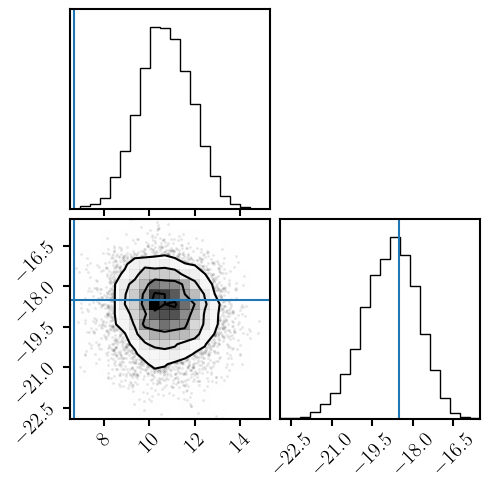

  0%|          | 0/10000 [00:00<?, ?it/s]

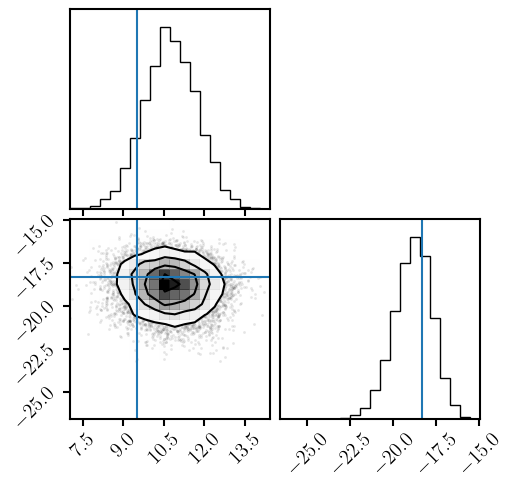

  0%|          | 0/10000 [00:00<?, ?it/s]

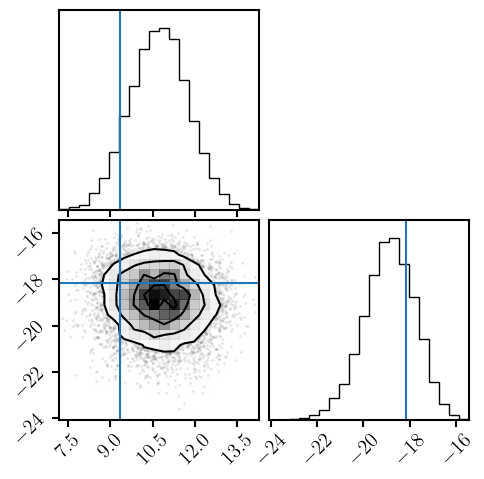

In [15]:
for i in range(3):
    samples = p_X_omegasig_S_z11.sample((10000,), x=test_omegasig[i]).cpu().numpy()
    fig = DFM.corner(samples)
    DFM.overplot_lines(fig, test_X[i].cpu())
    plt.show()

In [16]:
L = 1000
ichoose = np.random.choice(np.arange(test_omegasig.shape[0]), size=L, replace=False)

In [17]:
test_samples = p_X_omegasig_S_z11.sample_batched((1000,), x=test_omegasig[ichoose], show_progress_bars=False)
ecp_z11, alpha_z11 = tarp.get_tarp_coverage(test_samples.cpu().numpy(), test_X[ichoose].cpu().numpy())
mean_score_z11, std_score_z11 = mira(test_X[ichoose], test_samples[None,:].permute(0, 2, 1, 3), num_runs=100)

Mira MC runs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 415.99it/s]


(0.0, 1.0)

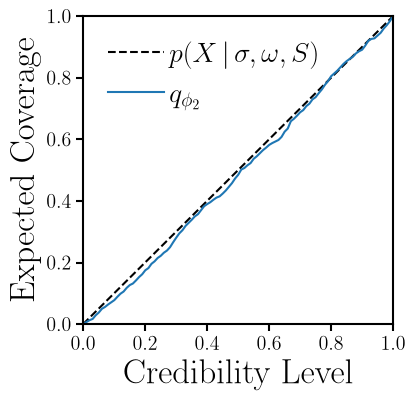

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label=r'$p(X\,|\,\sigma, \omega,S)$')
ax.plot(alpha_z11, ecp_z11, label=r'$q_{\phi_2}$')
ax.legend(fontsize=20, handletextpad=0.2)
ax.set_ylabel("Expected Coverage", fontsize=25)
ax.set_ylim(0, 1)
ax.set_xlabel("Credibility Level", fontsize=25)
ax.set_xlim(0, 1)

Text(0, 0.5, 'MIRA score')

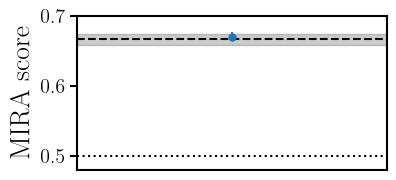

In [19]:
fig = plt.figure(figsize=(4,2))
sub = fig.add_subplot(111)
sub.fill_between([0., 1.], [2/3+np.sqrt(1/18/L), 2/3+np.sqrt(1/18/L)], [2/3-np.sqrt(1/18/L), 2/3-np.sqrt(1/18/L)], edgecolor='none', color='k', alpha=0.2)
sub.plot([0., 1.], [2/3, 2/3], c='k', ls='--')
sub.plot([0., 1.], [0.5, 0.5], c='k', ls=':')
sub.errorbar([0.5], [mean_score_z11.item()], yerr=[std_score_z11.item()], fmt='o', markersize=5)
sub.set_xlim(0., 1.)
sub.set_xticks([])
sub.set_ylim(0.48, 0.7)
sub.set_ylabel('MIRA score', fontsize=20)

  0%|          | 0/10000 [00:00<?, ?it/s]

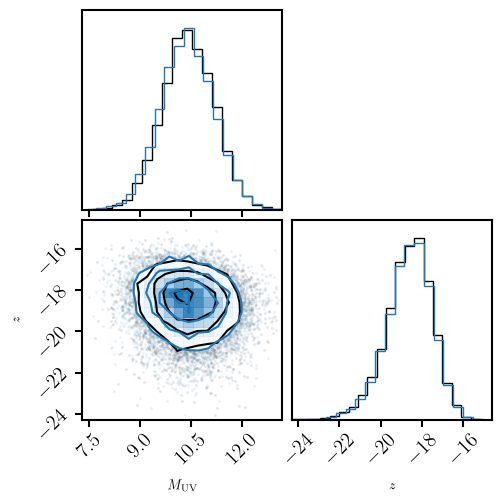

  0%|          | 0/10000 [00:00<?, ?it/s]

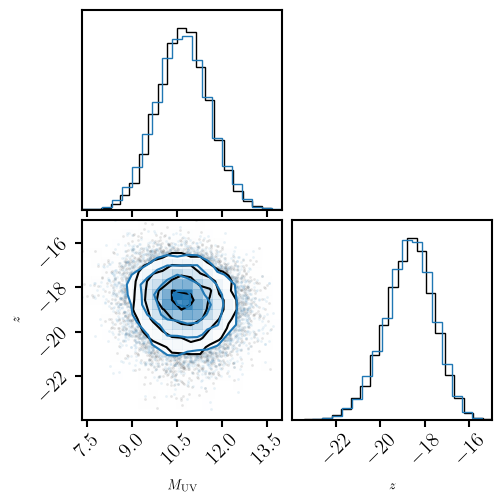

  0%|          | 0/10000 [00:00<?, ?it/s]

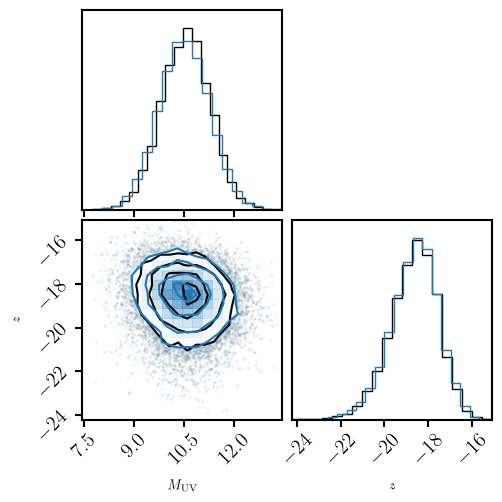

  0%|          | 0/10000 [00:00<?, ?it/s]

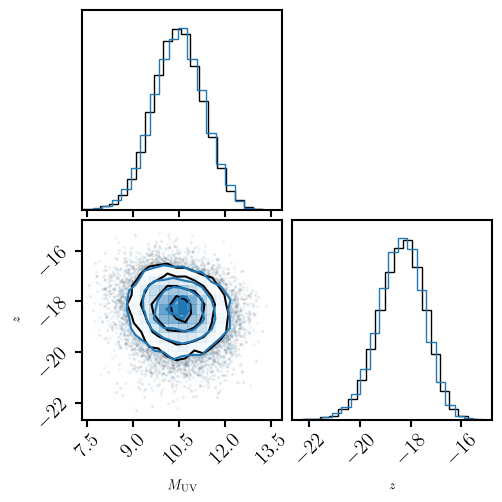

  0%|          | 0/10000 [00:00<?, ?it/s]

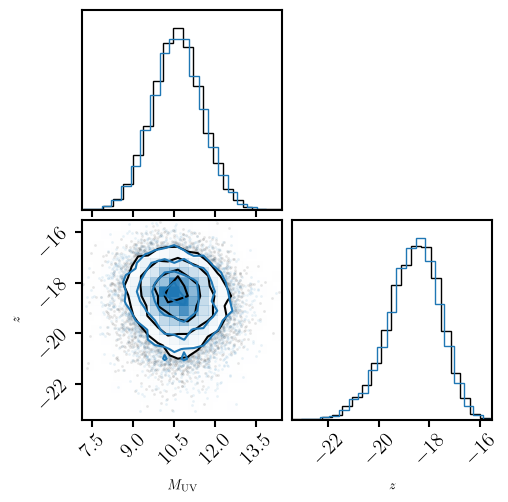

  0%|          | 0/10000 [00:00<?, ?it/s]

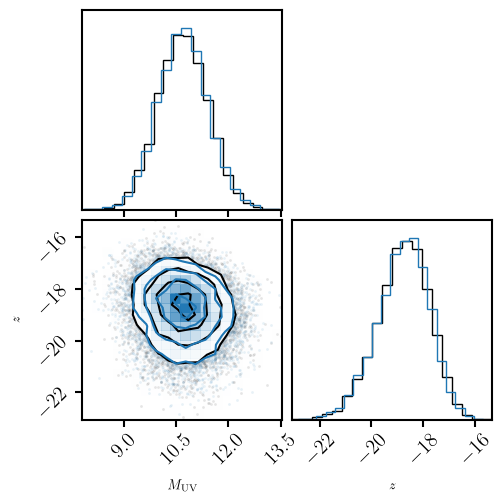

  0%|          | 0/10000 [00:00<?, ?it/s]

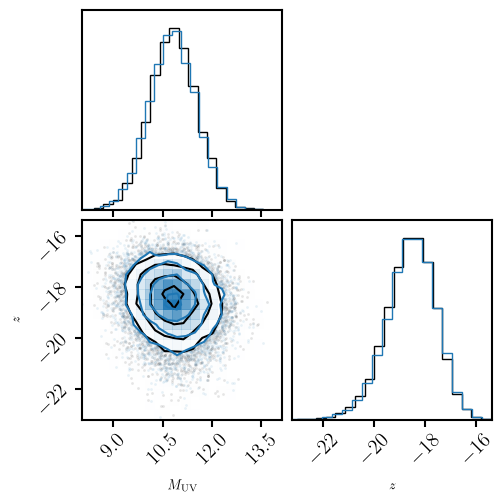

  0%|          | 0/10000 [00:00<?, ?it/s]

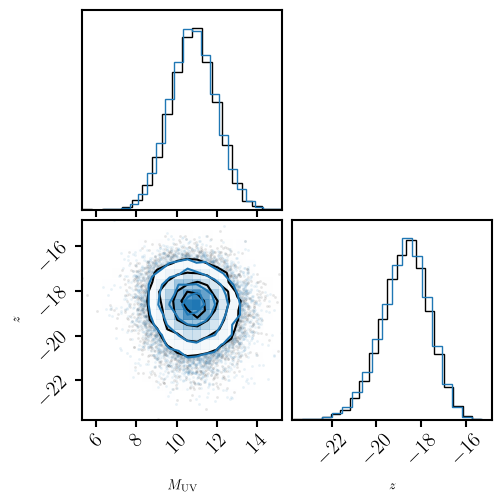

  0%|          | 0/10000 [00:00<?, ?it/s]

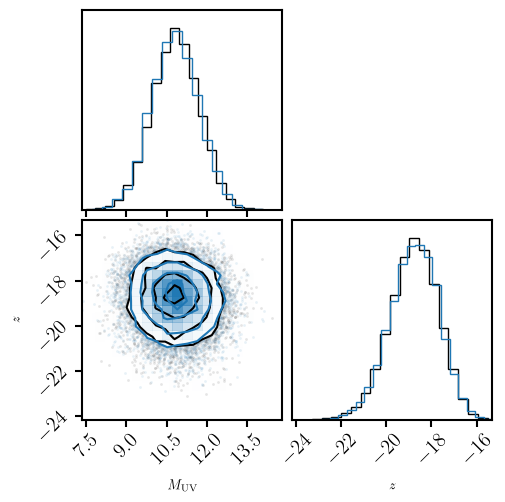

  0%|          | 0/10000 [00:00<?, ?it/s]

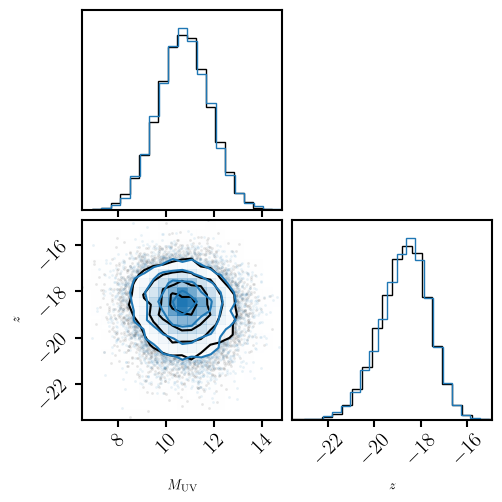

In [21]:
for i in np.random.choice(np.arange(test_X.shape[0]), size=10, replace=False): 
    _omega = test_omegas[i]
    _sig_z = test_Xsig[i,-2]
    _sig_Muv = test_Xsig[i,-1]

    Ng = 0
    mocks = [] 
    while Ng < 10000: 
        mock = FM.sampleLF(_omega, phi_amp=6e-3)
        select = FM.selection_function(mock, name='z11') 
        mock = mock[select]
        
        mock[:,0] += _sig_z * np.random.normal(size=mock.shape[0])
        mock[:,1] += _sig_Muv * np.random.normal(size=mock.shape[0])
        mocks.append(mock)
        Ng += mock.shape[0]
    mocks = np.vstack(mocks)
    
    _omegasig = np.concatenate([_omega, [_sig_z, _sig_Muv]])
    samples = p_X_omegasig_S_z11.sample((10000,), x=torch.tensor(_omegasig.astype(np.float32)).to('mps')).cpu()
    fig = DFM.corner(samples.numpy(), labels=[r"$M_{\rm UV}$", "$z$"], hist_kwargs={'density':True})
    _ = DFM.corner(mocks, labels=[r"$M_{\rm UV}$", "$z$"], fig=fig, color='C0', hist_kwargs={'density':True})
    plt.show()

# validate $z=9$ NLE

In [22]:
# construct test data
test_omegas, test_Xsig = [], []
for i in tqdm(range(Nmocks)): 
    # forward model 
    _mock = FM.forwardmodel(_test_omegas[i], name='z9', phi_amp=6e-3)

    test_omegas.append(np.tile(_test_omegas[i], (_mock.shape[0],1)))
    test_Xsig.append(_mock)
    
test_omegas = np.vstack(test_omegas)
test_Xsig = np.vstack(test_Xsig)

test_omegasig = torch.tensor(np.hstack([test_omegas, test_Xsig[:,-2:]]).astype(np.float32))
test_X = torch.tensor(test_Xsig[:,:2].astype(np.float32))


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:00<00:00, 16.65it/s]


In [23]:
p_X_omegasig_S_z9 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_down/q_X_omegasig_z9_down.14.pt', weights_only=False)

  0%|          | 0/10000 [00:00<?, ?it/s]

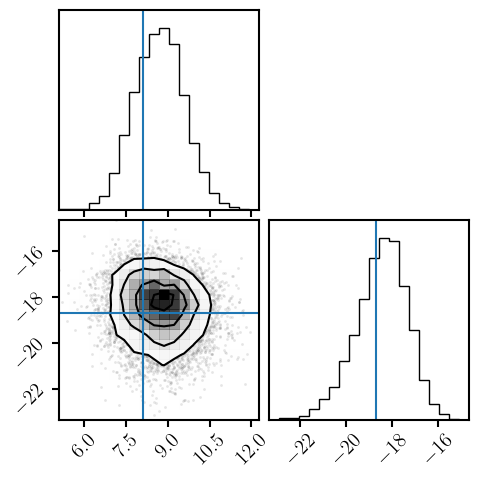

  0%|          | 0/10000 [00:00<?, ?it/s]

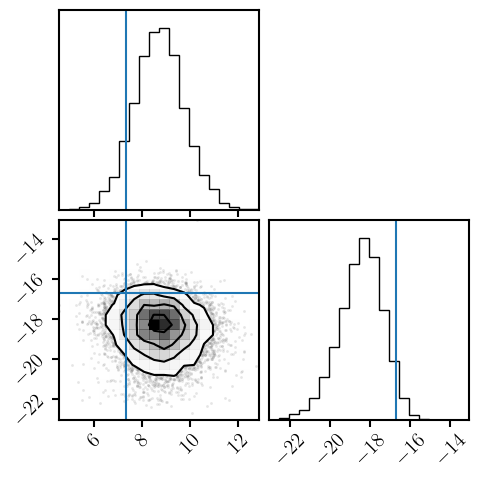

  0%|          | 0/10000 [00:00<?, ?it/s]

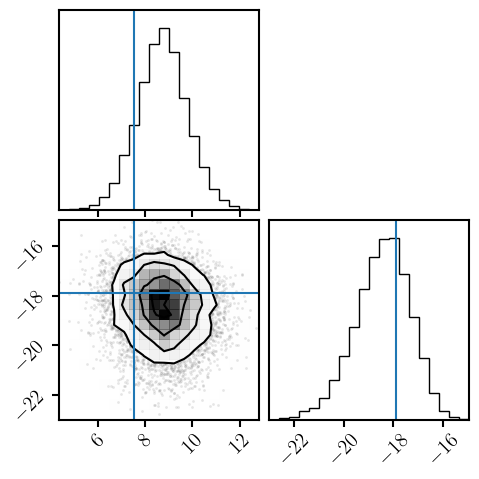

  0%|          | 0/10000 [00:00<?, ?it/s]

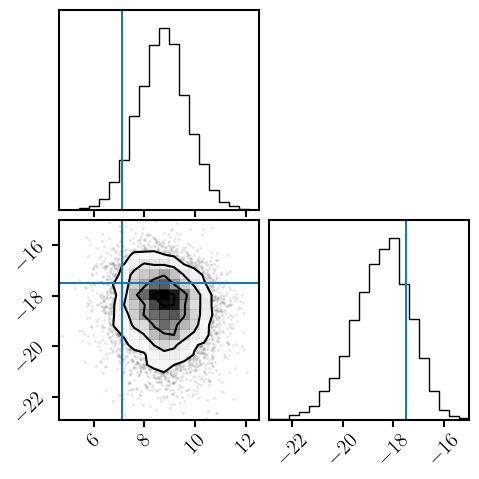

In [24]:
for i in range(10,14):
    samples = p_X_omegasig_S_z9.sample((10000,), x=test_omegasig[i]).cpu().numpy()
    fig = DFM.corner(samples)
    DFM.overplot_lines(fig, test_X[i].cpu())
    plt.show()

In [25]:
L = 1000
ichoose = np.random.choice(np.arange(test_omegasig.shape[0]), size=L, replace=False)

In [26]:
test_samples = p_X_omegasig_S_z9.sample_batched((1000,), x=test_omegasig[ichoose], show_progress_bars=False)
ecp_z9, alpha_z9 = tarp.get_tarp_coverage(test_samples.cpu().numpy(), test_X[ichoose].cpu().numpy())
mean_score_z9, std_score_z9 = mira(test_X[ichoose], test_samples[None,:].permute(0, 2, 1, 3), num_runs=100)


Mira MC runs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 378.82it/s]


(0.0, 1.0)

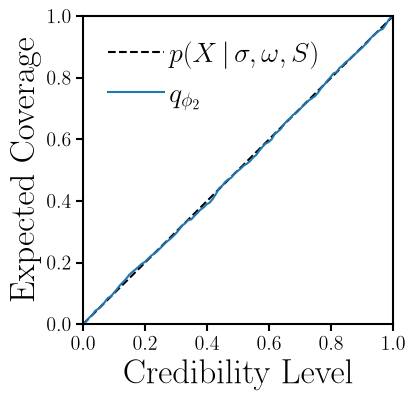

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label=r'$p(X\,|\,\sigma, \omega,S)$')
ax.plot(alpha_z9, ecp_z9, label=r'$q_{\phi_2}$')
ax.legend(fontsize=20, handletextpad=0.2)
ax.set_ylabel("Expected Coverage", fontsize=25)
ax.set_ylim(0, 1)
ax.set_xlabel("Credibility Level", fontsize=25)
ax.set_xlim(0, 1)

Text(0, 0.5, 'MIRA score')

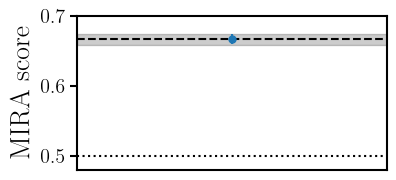

In [28]:
fig = plt.figure(figsize=(4,2))
sub = fig.add_subplot(111)
sub.fill_between([0., 1.], [2/3+np.sqrt(1/18/L), 2/3+np.sqrt(1/18/L)], [2/3-np.sqrt(1/18/L), 2/3-np.sqrt(1/18/L)], edgecolor='none', color='k', alpha=0.2)
sub.plot([0., 1.], [2/3, 2/3], c='k', ls='--')
sub.plot([0., 1.], [0.5, 0.5], c='k', ls=':')
sub.errorbar([0.5], [mean_score_z9.item()], yerr=[std_score_z9.item()], fmt='o', markersize=5)
sub.set_xlim(0., 1.)
sub.set_xticks([])
sub.set_ylim(0.48, 0.7)
sub.set_ylabel('MIRA score', fontsize=20)

  0%|          | 0/10000 [00:00<?, ?it/s]

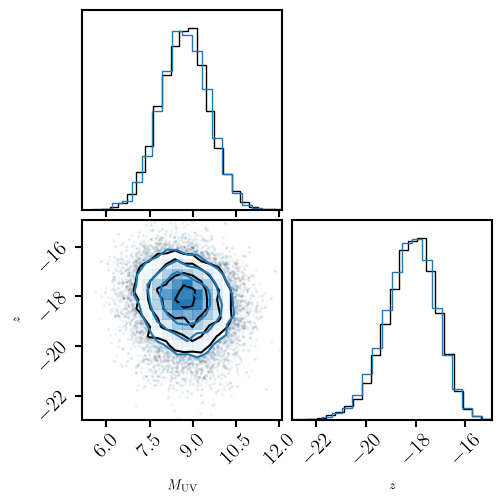

  0%|          | 0/10000 [00:00<?, ?it/s]

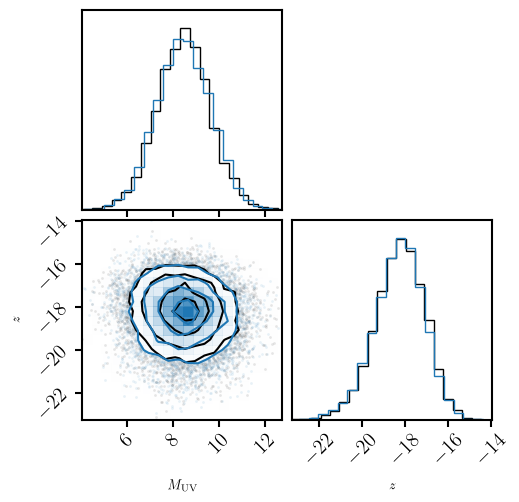

  0%|          | 0/10000 [00:00<?, ?it/s]

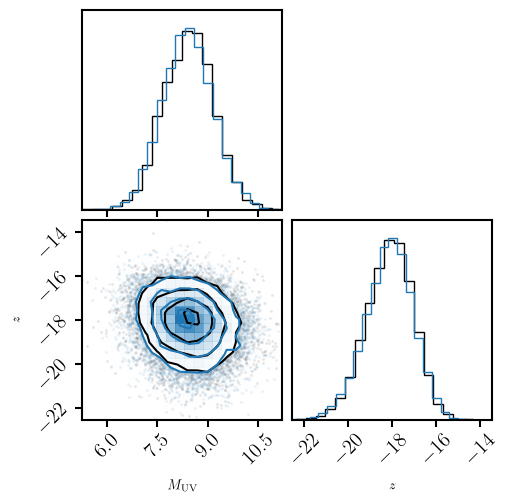

  0%|          | 0/10000 [00:00<?, ?it/s]

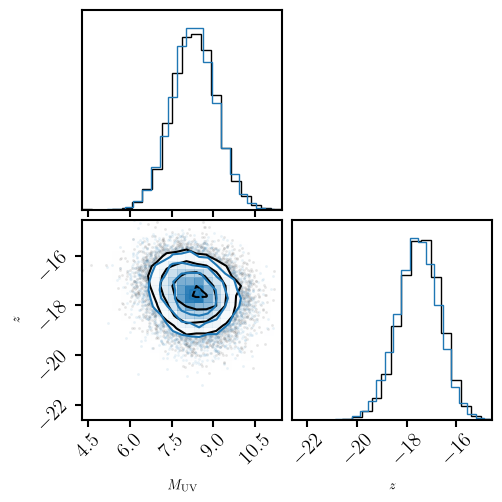

  0%|          | 0/10000 [00:00<?, ?it/s]

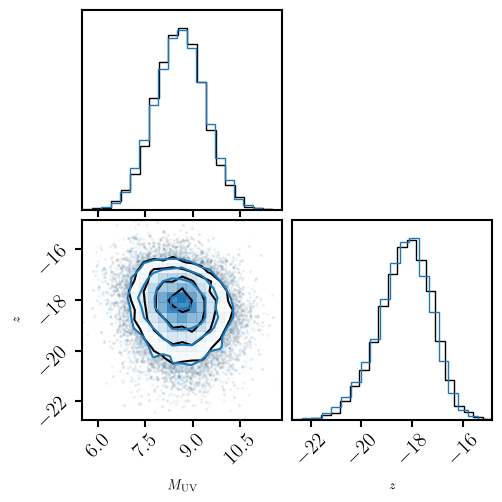

  0%|          | 0/10000 [00:00<?, ?it/s]

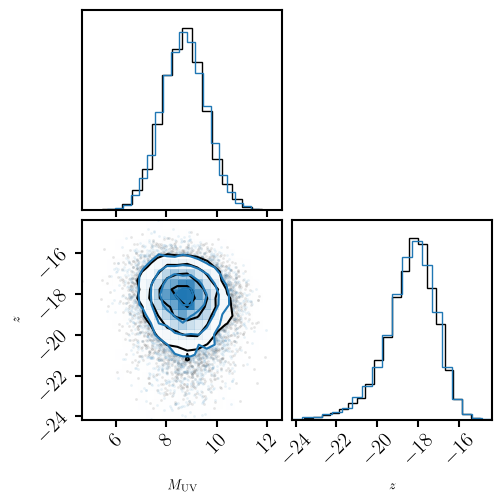

  0%|          | 0/10000 [00:00<?, ?it/s]

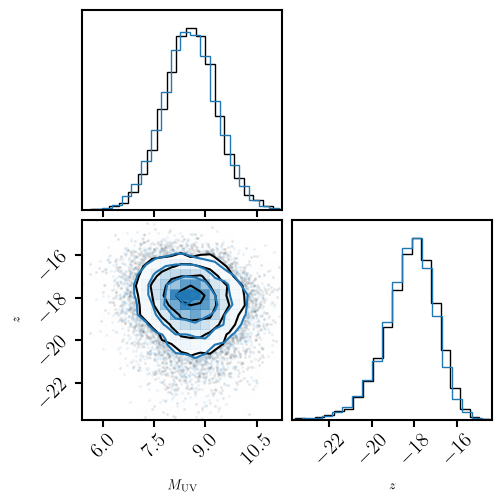

  0%|          | 0/10000 [00:00<?, ?it/s]

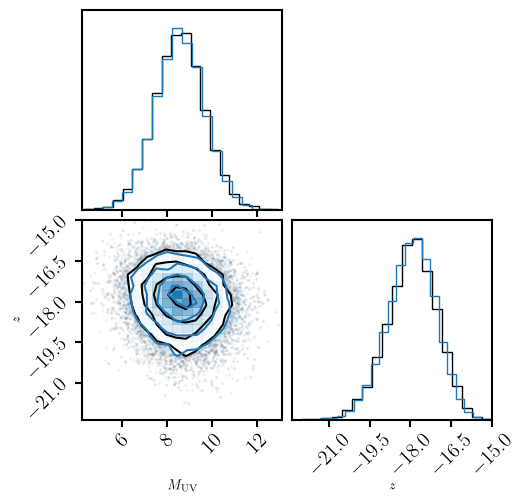

  0%|          | 0/10000 [00:00<?, ?it/s]

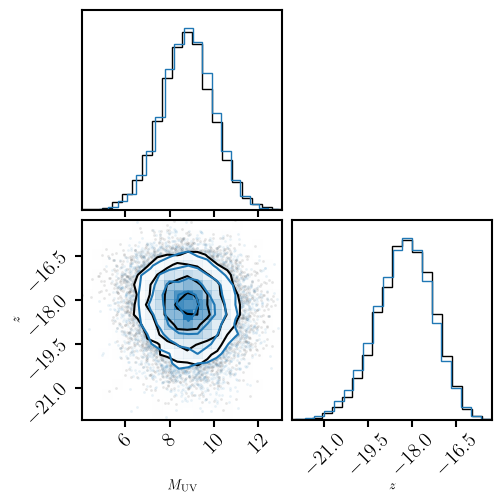

  0%|          | 0/10000 [00:00<?, ?it/s]

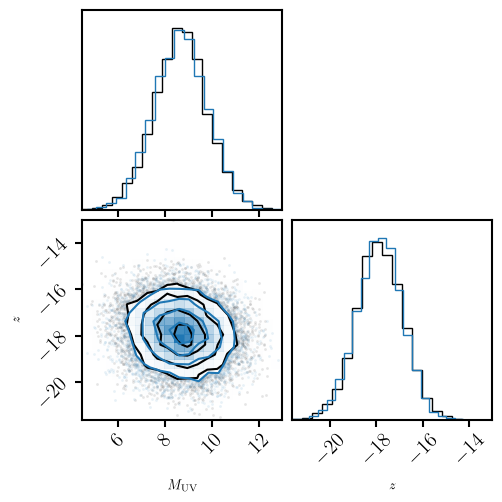

In [29]:
for i in np.random.choice(np.arange(test_X.shape[0]), size=10, replace=False): 
    _omega = test_omegas[i]
    _sig_z = test_Xsig[i,-2]
    _sig_Muv = test_Xsig[i,-1]

    Ng = 0
    mocks = [] 
    while Ng < 10000: 
        mock = FM.sampleLF(_omega, phi_amp=6e-3)
        select = FM.selection_function(mock, name='z9') 
        mock = mock[select]
        
        mock[:,0] += _sig_z * np.random.normal(size=mock.shape[0])
        mock[:,1] += _sig_Muv * np.random.normal(size=mock.shape[0])
        mocks.append(mock)
        Ng += mock.shape[0]
    mocks = np.vstack(mocks)
    
    _omegasig = np.concatenate([_omega, [_sig_z, _sig_Muv]])
    samples = p_X_omegasig_S_z9.sample((10000,), x=torch.tensor(_omegasig.astype(np.float32))).cpu()
    fig = DFM.corner(samples.numpy(), labels=[r"$M_{\rm UV}$", "$z$"], hist_kwargs={'density':True})
    _ = DFM.corner(mocks, labels=[r"$M_{\rm UV}$", "$z$"], fig=fig, color='C0', hist_kwargs={'density':True})
    plt.show()

# validation plots

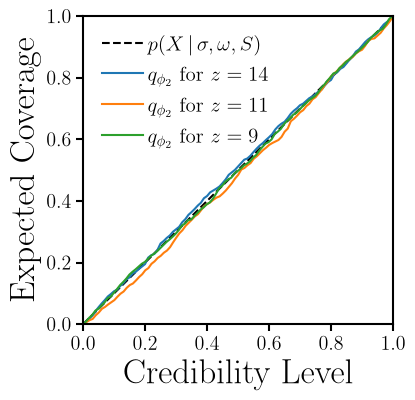

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label=r'$p(X\,|\,\sigma, \omega,S)$')
ax.plot(alpha_z14, ecp_z14, label=r'$q_{\phi_2}$ for $z=14$')
ax.plot(alpha_z11, ecp_z11, label=r'$q_{\phi_2}$ for $z=11$')
ax.plot(alpha_z9, ecp_z9, label=r'$q_{\phi_2}$ for $z=9$')
ax.legend(fontsize=15, handletextpad=0.2)
ax.set_ylabel("Expected Coverage", fontsize=25)
ax.set_ylim(0, 1)
ax.set_xlabel("Credibility Level", fontsize=25)
ax.set_xlim(0, 1)
fig.savefig('likelihood_tarp.pdf', bbox_inches='tight') 

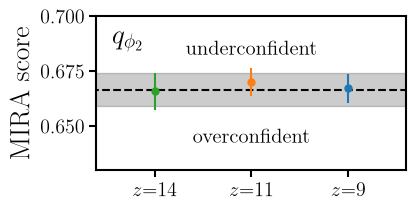

In [32]:
fig = plt.figure(figsize=(4,2))
sub = fig.add_subplot(111)
sub.fill_between([0., 1.], [2/3+np.sqrt(1/18/L), 2/3+np.sqrt(1/18/L)], [2/3-np.sqrt(1/18/L), 2/3-np.sqrt(1/18/L)], edgecolor='none', color='k', alpha=0.2)
sub.plot([0., 1.], [2/3, 2/3], c='k', ls='--')

sub.errorbar([0.25], [mean_score_z14.item()], yerr=[std_score_z14.item()], c='C2', fmt='o', markersize=5)
sub.errorbar([0.50], [mean_score_z11.item()], yerr=[std_score_z11.item()], c='C1', fmt='o', markersize=5)
sub.errorbar([0.75], [mean_score_z9.item()], yerr=[std_score_z9.item()], c='C0', fmt='o', markersize=5)

sub.text(0.5, 0.685, 'underconfident', ha='center', va='center', fontsize=15)
sub.text(0.5, 0.645, 'overconfident', ha='center', va='center', fontsize=15)

sub.text(0.05, 0.95, r'$q_{\phi_2}$', fontsize=20, transform=sub.transAxes, ha='left', va='top')
sub.set_xlim(0.1, 0.9)
sub.set_xticks([0.25, 0.5, 0.75])
sub.set_xticklabels(['$z{=}14$', '$z{=}11$', '$z{=}9$'])
sub.set_ylim(0.63, 0.7)
sub.set_ylabel('MIRA score', fontsize=20)
fig.savefig('likelihood_mira.pdf', bbox_inches='tight') 